<a href="https://colab.research.google.com/github/NanditaPatil-dotcom/PhysSAE/blob/main/PhysSAE_ICA_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Setup

In [1]:
import os, time, math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.decomposition import FastICA

# reproducibility
torch.manual_seed(0); np.random.seed(0)
torch.set_num_threads(4)

# publication style
mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 220,
    "font.family": "serif", "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.titlesize": 11, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
})

os.makedirs("artifacts", exist_ok=True)
os.makedirs("figures", exist_ok=True)

# hyperparams
HIDDEN = 40        # PINN hidden width
N_LAYERS = 4       # number of hidden linear layers
PINN_ITERS = 4000
N_COMPONENTS = HIDDEN

# 2. PINN architecture


In [2]:
class PINN(nn.Module):
    def __init__(self, out_dim=1, layers=None):
        super().__init__()

        layers = layers or ([2] +[HIDDEN]*N_LAYERS +[out_dim])

        self.net = nn.ModuleList(
            [nn.Linear(layers[i], layers[i+1])
             for i in range(len(layers)-1)]
        )

        self.act = nn.Tanh()

        for m in self.net:
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)

        self._hidden = None

    def forward(self,x,t):
        h = torch.cat([x,t],dim=1)

        for layer in self.net[:-1]:
            h = self.act(layer(h))

        self._hidden = h

        return self.net[-1](h)


# 3. Training PINN

In [3]:
def train_pinn(loss_fn, n_iter=PINN_ITERS, log_every=400, tag="pinn",out_dim=1):
    model = PINN(out_dim=out_dim)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    hist = []; t0 = time.time()
    for it in range(n_iter):
        opt.zero_grad()
        loss, parts = loss_fn(model)
        loss.backward(); opt.step()
        hist.append(parts)
        if it % log_every == 0:
            print(f"[{tag}] it {it:5d} | bc {parts[0]:.2e} ic {parts[1]:.2e} f {parts[2]:.2e} | {time.time()-t0:.0f}s")
    print(f"[{tag}] total {time.time()-t0:.0f}s")
    return model, np.array(hist)

# 4. Train on PDEs

## 1. Train the Burgers PINN



In [4]:
nu = 0.01/np.pi
def burgers_loss(model):
    n_b, n_i, n_f = 100, 100, 2500
    x_b1 = -torch.ones(n_b,1); x_b2 = torch.ones(n_b,1); t_b = torch.rand(n_b,1)
    x_i = torch.rand(n_i,1)*2-1; t_i = torch.zeros(n_i,1); u_i = -torch.sin(np.pi*x_i)
    x_f = torch.rand(n_f,1)*2-1; t_f = torch.rand(n_f,1)
    u_b1, u_b2, u_ip = model(x_b1, t_b), model(x_b2, t_b), model(x_i, t_i)
    xfg, tfg = x_f.clone().requires_grad_(True), t_f.clone().requires_grad_(True)
    u = model(xfg, tfg)
    u_t = torch.autograd.grad(u, tfg, torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, xfg, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, xfg, torch.ones_like(u_x), create_graph=True)[0]
    r = u_t + u*u_x - nu*u_xx
    l_bc = (u_b1**2).mean() + (u_b2**2).mean()
    l_ic = ((u_ip - u_i)**2).mean()
    l_f  = (r**2).mean()
    return 100*l_bc + 100*l_ic + l_f, (l_bc.item(), l_ic.item(), l_f.item())

if os.path.exists("artifacts/burgers_pinn.pt"):
    pinn_b = PINN(out_dim=1); pinn_b.load_state_dict(torch.load("artifacts/burgers_pinn.pt"))
    hist_b = np.load("artifacts/burgers_hist.npy")
    print("Loaded cached Burgers PINN.")
else:
    pinn_b, hist_b = train_pinn(burgers_loss, tag="burgers")
    torch.save(pinn_b.state_dict(), "artifacts/burgers_pinn.pt")
    np.save("artifacts/burgers_hist.npy", hist_b)


[burgers] it     0 | bc 1.10e-02 ic 5.70e-01 f 1.29e-02 | 0s
[burgers] it   400 | bc 1.10e-03 ic 8.67e-03 f 7.04e-01 | 8s
[burgers] it   800 | bc 4.77e-04 ic 7.83e-04 f 4.56e-01 | 18s
[burgers] it  1200 | bc 3.47e-04 ic 3.61e-04 f 4.19e-01 | 25s
[burgers] it  1600 | bc 1.82e-04 ic 1.95e-04 f 4.21e-01 | 33s
[burgers] it  2000 | bc 1.11e-04 ic 2.32e-04 f 4.05e-01 | 40s
[burgers] it  2400 | bc 2.06e-04 ic 1.84e-04 f 4.13e-01 | 49s
[burgers] it  2800 | bc 4.33e-05 ic 1.25e-04 f 3.53e-01 | 56s
[burgers] it  3200 | bc 1.80e-04 ic 2.56e-04 f 3.65e-01 | 64s
[burgers] it  3600 | bc 1.67e-03 ic 4.62e-04 f 3.67e-01 | 71s
[burgers] total 78s


## 2. Train the Allen–Cahn PINN


In [5]:
D_AC = 1e-4
def allencahn_loss(model):
    n_b, n_i, n_f = 100, 100, 2500
    t_b = torch.rand(n_b,1)
    x_bl = -torch.ones(n_b,1); x_br = torch.ones(n_b,1)
    x_i = torch.rand(n_i,1)*2-1; t_i = torch.zeros(n_i,1)
    u_i = (x_i**2) * torch.cos(np.pi*x_i)
    x_f = torch.rand(n_f,1)*2-1; t_f = torch.rand(n_f,1)
    # periodic BC: u(-1,t)=u(1,t) and u_x(-1,t)=u_x(1,t)
    xbl_g, xbr_g = x_bl.clone().requires_grad_(True), x_br.clone().requires_grad_(True)
    u_bl, u_br = model(xbl_g, t_b), model(xbr_g, t_b)
    u_bl_x = torch.autograd.grad(u_bl, xbl_g, torch.ones_like(u_bl), create_graph=True)[0]
    u_br_x = torch.autograd.grad(u_br, xbr_g, torch.ones_like(u_br), create_graph=True)[0]
    l_bc = ((u_bl-u_br)**2).mean() + ((u_bl_x-u_br_x)**2).mean()
    u_ip = model(x_i, t_i); l_ic = ((u_ip - u_i)**2).mean()
    xfg, tfg = x_f.clone().requires_grad_(True), t_f.clone().requires_grad_(True)
    u = model(xfg, tfg)
    u_t = torch.autograd.grad(u, tfg, torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, xfg, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, xfg, torch.ones_like(u_x), create_graph=True)[0]
    r = u_t - D_AC*u_xx + 5.0*u**3 - 5.0*u
    l_f = (r**2).mean()
    return 100*l_bc + 100*l_ic + l_f, (l_bc.item(), l_ic.item(), l_f.item())

if os.path.exists("artifacts/allencahn_pinn.pt"):
    pinn_a = PINN(out_dim=1); pinn_a.load_state_dict(torch.load("artifacts/allencahn_pinn.pt"))
    hist_a = np.load("artifacts/allencahn_hist.npy")
    print("Loaded cached Allen-Cahn PINN.")
else:
    pinn_a, hist_a = train_pinn(allencahn_loss, tag="allencahn")
    torch.save(pinn_a.state_dict(), "artifacts/allencahn_pinn.pt")
    np.save("artifacts/allencahn_hist.npy", hist_a)


[allencahn] it     0 | bc 3.69e-02 ic 1.12e-01 f 1.38e-01 | 0s
[allencahn] it   400 | bc 2.12e-03 ic 2.07e-02 f 1.16e+00 | 7s
[allencahn] it   800 | bc 8.14e-04 ic 3.23e-03 f 1.07e+00 | 15s
[allencahn] it  1200 | bc 5.53e-04 ic 1.31e-03 f 1.03e+00 | 22s
[allencahn] it  1600 | bc 1.75e-04 ic 8.39e-04 f 9.82e-01 | 29s
[allencahn] it  2000 | bc 3.41e-04 ic 5.95e-04 f 9.79e-01 | 37s
[allencahn] it  2400 | bc 1.46e-04 ic 7.61e-04 f 1.08e+00 | 45s
[allencahn] it  2800 | bc 8.46e-05 ic 7.73e-04 f 9.64e-01 | 52s
[allencahn] it  3200 | bc 1.03e-04 ic 7.99e-04 f 1.01e+00 | 59s
[allencahn] it  3600 | bc 8.15e-05 ic 9.58e-04 f 9.20e-01 | 67s
[allencahn] total 74s


## 3. Heat Equation

In [6]:
def heat_loss(model):
    n_b, n_i, n_f = 100, 100, 2500
    x_b1 = -torch.ones(n_b,1)
    x_b2 =  torch.ones(n_b,1)
    t_b = torch.rand(n_b,1)
    u_b1 = model(x_b1, t_b)
    u_b2 = model(x_b2, t_b)
    x_i = 2*torch.rand(n_i,1) - 1
    t_i = torch.zeros(n_i,1)
    u_i_true = torch.exp(-5*x_i**2)
    u_i = model(x_i, t_i)
    x_f = 2*torch.rand(n_f,1) - 1
    t_f = torch.rand(n_f,1)
    xfg = x_f.clone().requires_grad_(True)
    tfg = t_f.clone().requires_grad_(True)
    u = model(xfg, tfg)
    u_t = torch.autograd.grad(u,tfg,torch.ones_like(u),create_graph=True)[0]
    u_x = torch.autograd.grad(u,xfg,torch.ones_like(u),create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x,xfg,torch.ones_like(u_x),create_graph=True)[0]

    r = u_t - u_xx

    l_bc = (u_b1**2).mean() + (u_b2**2).mean()
    l_ic = ((u_i - u_i_true)**2).mean()
    l_f = (r**2).mean()
    total = 100*l_bc + 100*l_ic + l_f
    return total, (l_bc.item(),l_ic.item(),l_f.item())

if os.path.exists("artifacts/heat_pinn.pt"):
    pinn_h = PINN(out_dim=1)
    pinn_h.load_state_dict(torch.load("artifacts/heat_pinn.pt"))
    hist_h = np.load("artifacts/heat_hist.npy")
    print("Loaded cached Heat PINN.")
else:
    pinn_h, hist_h = train_pinn(heat_loss,tag="heat")
    torch.save(pinn_h.state_dict(),"artifacts/heat_pinn.pt")
    np.save("artifacts/heat_hist.npy",hist_h)

[heat] it     0 | bc 1.51e-01 ic 3.47e-01 f 1.63e-01 | 0s
[heat] it   400 | bc 5.80e-04 ic 2.92e-03 f 3.62e-01 | 7s
[heat] it   800 | bc 4.20e-04 ic 7.76e-04 f 1.70e-01 | 13s
[heat] it  1200 | bc 2.65e-04 ic 4.71e-04 f 9.77e-02 | 22s
[heat] it  1600 | bc 1.42e-04 ic 2.70e-04 f 5.95e-02 | 29s
[heat] it  2000 | bc 8.54e-05 ic 1.85e-04 f 3.60e-02 | 36s
[heat] it  2400 | bc 6.82e-05 ic 1.51e-04 f 2.13e-02 | 45s
[heat] it  2800 | bc 5.51e-05 ic 6.39e-05 f 1.72e-02 | 52s
[heat] it  3200 | bc 2.23e-04 ic 7.96e-05 f 1.40e-02 | 58s
[heat] it  3600 | bc 1.08e-05 ic 3.01e-05 f 1.22e-02 | 65s
[heat] total 71s


## 4. schrodinger equation - single soliton

In [7]:
def schrodinger_loss_single(model):

    n_b, n_i, n_f = 100, 100, 2500
    x_b1 = -5*torch.ones(n_b,1)
    x_b2 =  5*torch.ones(n_b,1)
    t_b  = torch.rand(n_b,1)
    uv_b1 = model(x_b1,t_b)
    uv_b2 = model(x_b2,t_b)
    u_b1 = uv_b1[:,0:1]
    v_b1 = uv_b1[:,1:2]
    u_b2 = uv_b2[:,0:1]
    v_b2 = uv_b2[:,1:2]

    x_i = -5 + 10*torch.rand(n_i,1)
    t_i = torch.zeros(n_i,1)

    uv_i = model(x_i,t_i)

    u_i = uv_i[:,0:1]
    v_i = uv_i[:,1:2]

    u_true = 2.0 / torch.cosh(x_i)
    v_true = torch.zeros_like(x_i)

    x_f = -5 + 10*torch.rand(n_f,1)
    t_f = torch.rand(n_f,1)
    xfg = x_f.clone().requires_grad_(True)
    tfg = t_f.clone().requires_grad_(True)
    uv = model(xfg,tfg)
    u = uv[:,0:1]
    v = uv[:,1:2]

    u_t = torch.autograd.grad(u, tfg,torch.ones_like(u),create_graph=True)[0]
    v_t = torch.autograd.grad(v, tfg,torch.ones_like(v),create_graph=True)[0]
    u_x = torch.autograd.grad(u, xfg,torch.ones_like(u),create_graph=True)[0]
    v_x = torch.autograd.grad(v, xfg,torch.ones_like(v),create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, xfg,torch.ones_like(u_x),create_graph=True)[0]
    v_xx = torch.autograd.grad(v_x, xfg,torch.ones_like(v_x),create_graph=True)[0]
    amp2 = u*u + v*v
    r_u = u_t + 0.5*v_xx + amp2*v
    r_v = v_t - 0.5*u_xx - amp2*u
    l_bc = ((u_b1**2).mean()+ (v_b1**2).mean()+ (u_b2**2).mean()+ (v_b2**2).mean())
    l_ic = (((u_i-u_true)**2).mean()+ ((v_i-v_true)**2).mean())
    l_f = ((r_u**2).mean()+ (r_v**2).mean())
    total = 100*l_bc + 100*l_ic + l_f

    return total, (l_bc.item(),l_ic.item(),l_f.item())


if os.path.exists("artifacts/schrodinger_pinn_single.pt"):
    pinn_s_s = PINN(out_dim=2)
    pinn_s_s.load_state_dict(torch.load("artifacts/schrodinger_pinn_single.pt"))
    hist_s_s = np.load("artifacts/schrodinger_hist_single.npy")
    print("Loaded cached Schrödinger single PINN.")

else:
    pinn_s_s, hist_s_s = train_pinn(schrodinger_loss_single,tag="schrodinger single",out_dim=2)
    torch.save(pinn_s_s.state_dict(),"artifacts/schrodinger_pinn_single.pt")
    np.save("artifacts/schrodinger_hist_single.npy",hist_s_s)

[schrodinger single] it     0 | bc 8.39e-01 ic 1.03e+00 f 2.95e-02 | 0s
[schrodinger single] it   400 | bc 2.24e-04 ic 1.20e-03 f 6.64e-01 | 12s
[schrodinger single] it   800 | bc 7.24e-05 ic 5.37e-04 f 4.29e-01 | 24s
[schrodinger single] it  1200 | bc 4.39e-05 ic 2.20e-04 f 3.39e-01 | 35s
[schrodinger single] it  1600 | bc 4.14e-05 ic 1.41e-04 f 2.27e-01 | 47s
[schrodinger single] it  2000 | bc 5.14e-05 ic 1.62e-04 f 1.91e-01 | 59s
[schrodinger single] it  2400 | bc 1.97e-04 ic 1.93e-04 f 1.63e-01 | 70s
[schrodinger single] it  2800 | bc 1.89e-04 ic 1.19e-04 f 1.65e-01 | 83s
[schrodinger single] it  3200 | bc 3.28e-05 ic 7.29e-05 f 1.59e-01 | 94s
[schrodinger single] it  3600 | bc 5.95e-05 ic 8.82e-05 f 1.37e-01 | 106s
[schrodinger single] total 118s


## 5. schrodinger equation - moving soliton

In [8]:
def schrodinger_loss_moving(model):

    n_b, n_i, n_f = 100, 100, 2500
    x_b1 = -5*torch.ones(n_b,1)
    x_b2 =  5*torch.ones(n_b,1)
    t_b  = torch.rand(n_b,1)
    uv_b1 = model(x_b1,t_b)
    uv_b2 = model(x_b2,t_b)
    u_b1 = uv_b1[:,0:1]
    v_b1 = uv_b1[:,1:2]
    u_b2 = uv_b2[:,0:1]
    v_b2 = uv_b2[:,1:2]
    x_i = -5 + 10*torch.rand(n_i,1)
    t_i = torch.zeros(n_i,1)

    uv_i = model(x_i,t_i)

    u_i = uv_i[:,0:1]
    v_i = uv_i[:,1:2]

    eta = 2.0
    v0  = 2.0

    amp0 = eta / torch.cosh(eta*x_i)

    u_true = amp0 * torch.cos(v0*x_i)
    v_true = amp0 * torch.sin(v0*x_i)
    x_f = -5 + 10*torch.rand(n_f,1)
    t_f = torch.rand(n_f,1)
    xfg = x_f.clone().requires_grad_(True)
    tfg = t_f.clone().requires_grad_(True)
    uv = model(xfg,tfg)
    u = uv[:,0:1]
    v = uv[:,1:2]

    u_t = torch.autograd.grad(u, tfg,torch.ones_like(u),create_graph=True)[0]
    v_t = torch.autograd.grad(v, tfg,torch.ones_like(v),create_graph=True)[0]
    u_x = torch.autograd.grad(u, xfg,torch.ones_like(u),create_graph=True)[0]
    v_x = torch.autograd.grad(v, xfg,torch.ones_like(v),create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, xfg,torch.ones_like(u_x),create_graph=True)[0]
    v_xx = torch.autograd.grad(v_x, xfg,torch.ones_like(v_x),create_graph=True)[0]
    amp2 = u*u + v*v
    r_u = u_t + 0.5*v_xx + amp2*v
    r_v = v_t - 0.5*u_xx - amp2*u
    l_bc = ((u_b1**2).mean()+ (v_b1**2).mean()+ (u_b2**2).mean()+ (v_b2**2).mean())
    l_ic = (((u_i-u_true)**2).mean()+ ((v_i-v_true)**2).mean())
    l_f = ((r_u**2).mean()+ (r_v**2).mean())
    total = 100*l_bc + 100*l_ic + l_f

    return total, (l_bc.item(),l_ic.item(),l_f.item())


try:
    if os.path.exists("artifacts/schrodinger_pinn_moving.pt") and \
       os.path.exists("artifacts/schrodinger_hist_moving.npy"):
        pinn_s_m = PINN(out_dim=2)
        pinn_s_m.load_state_dict(torch.load("artifacts/schrodinger_pinn_moving.pt"))
        hist_s_m = np.load("artifacts/schrodinger_hist_moving.npy")
        print("Loaded cached Schrödinger moving PINN.")

    else:
        pinn_s_m, hist_s_m = train_pinn(schrodinger_loss_moving,tag="schrodinger moving",out_dim=2)
        torch.save(pinn_s_m.state_dict(),"artifacts/schrodinger_pinn_moving.pt")
        np.save("artifacts/schrodinger_hist_moving.npy",hist_s_m)

except FileNotFoundError:
    print("Cached files not found or inaccessible; retraining Schrödinger moving PINN.")
    pinn_s_m, hist_s_m = train_pinn(schrodinger_loss_moving,tag="schrodinger moving",out_dim=2)
    torch.save(pinn_s_m.state_dict(),"artifacts/schrodinger_pinn_moving.pt")
    np.save("artifacts/schrodinger_hist_moving.npy",hist_s_m)

[schrodinger moving] it     0 | bc 4.17e-01 ic 4.80e-01 f 8.31e-02 | 0s
[schrodinger moving] it   400 | bc 4.70e-04 ic 5.20e-03 f 7.07e-01 | 12s
[schrodinger moving] it   800 | bc 2.86e-04 ic 2.06e-03 f 3.42e-01 | 23s
[schrodinger moving] it  1200 | bc 2.37e-04 ic 8.85e-04 f 2.05e-01 | 35s
[schrodinger moving] it  1600 | bc 5.40e-05 ic 3.26e-04 f 1.88e-01 | 47s
[schrodinger moving] it  2000 | bc 3.17e-05 ic 2.44e-04 f 1.39e-01 | 58s
[schrodinger moving] it  2400 | bc 4.34e-05 ic 1.52e-04 f 1.25e-01 | 70s
[schrodinger moving] it  2800 | bc 1.61e-05 ic 7.71e-05 f 9.61e-02 | 82s
[schrodinger moving] it  3200 | bc 2.76e-05 ic 7.82e-05 f 7.92e-02 | 93s
[schrodinger moving] it  3600 | bc 1.77e-05 ic 5.24e-05 f 7.90e-02 | 105s
[schrodinger moving] total 116s


## 6. Convection equation

In [9]:
def convection_loss(model, beta):

    n_b, n_i, n_f = 100, 100, 2500

    # periodic BC
    t_b = torch.rand(n_b,1)
    x_bl = -torch.ones(n_b,1)
    x_br =  torch.ones(n_b,1)
    u_bl = model(x_bl, t_b)
    u_br = model(x_br, t_b)

    # periodic derivative BC
    xbl_g = x_bl.clone().requires_grad_(True)
    xbr_g = x_br.clone().requires_grad_(True)

    u_bl_g = model(xbl_g, t_b)
    u_br_g = model(xbr_g, t_b)

    u_bl_x = torch.autograd.grad(u_bl_g,xbl_g,torch.ones_like(u_bl_g),create_graph=True)[0]
    u_br_x = torch.autograd.grad(u_br_g,xbr_g,torch.ones_like(u_br_g),create_graph=True)[0]
    l_bc = ((u_bl - u_br)**2).mean() + ((u_bl_x - u_br_x)**2).mean()

    # initial condition

    x_i = 2*torch.rand(n_i,1) - 1
    t_i = torch.zeros(n_i,1)

    u_true = torch.sin(np.pi*x_i)

    u_i = model(x_i,t_i)

    l_ic = ((u_i - u_true)**2).mean()

    # residual points

    x_f = 2*torch.rand(n_f,1) - 1
    t_f = torch.rand(n_f,1)

    xfg = x_f.clone().requires_grad_(True)
    tfg = t_f.clone().requires_grad_(True)

    u = model(xfg,tfg)
    u_t = torch.autograd.grad(u,tfg,torch.ones_like(u),create_graph=True)[0]
    u_x = torch.autograd.grad(u,xfg,torch.ones_like(u),create_graph=True)[0]

    r = u_t + beta*u_x
    l_f = (r**2).mean()
    total = 100*l_bc + 100*l_ic + l_f
    return total, (l_bc.item(),l_ic.item(),l_f.item())

BETAS = [1,50]

conv_models = {}
conv_hists  = {}

for beta in BETAS:

    fname_model = f"artifacts/convection_beta{beta}.pt"
    fname_hist  = f"artifacts/convection_beta{beta}_hist.npy"

    if os.path.exists(fname_model):

        model = PINN(out_dim=1)
        model.load_state_dict(torch.load(fname_model))
        hist = np.load(fname_hist)
        print(f"Loaded cached convection PINN beta={beta}")

    else:

        loss_fn = lambda m, b=beta: convection_loss(m,b)
        model, hist = train_pinn(loss_fn,tag=f"conv_beta{beta}")
        torch.save(model.state_dict(),fname_model)
        np.save(fname_hist,hist)

    conv_models[beta] = model
    conv_hists[beta]  = hist

[conv_beta1] it     0 | bc 1.22e+00 ic 9.77e-01 f 3.24e-01 | 0s
[conv_beta1] it   400 | bc 2.50e-03 ic 1.11e-02 f 1.02e+00 | 5s
[conv_beta1] it   800 | bc 5.66e-04 ic 1.25e-03 f 8.46e-01 | 10s
[conv_beta1] it  1200 | bc 5.37e-04 ic 1.04e-03 f 6.57e-01 | 16s
[conv_beta1] it  1600 | bc 9.09e-04 ic 6.61e-04 f 5.79e-01 | 21s
[conv_beta1] it  2000 | bc 1.37e-03 ic 6.40e-04 f 5.13e-01 | 26s
[conv_beta1] it  2400 | bc 5.82e-04 ic 1.55e-04 f 4.44e-01 | 31s
[conv_beta1] it  2800 | bc 2.48e-04 ic 1.73e-04 f 3.81e-01 | 36s
[conv_beta1] it  3200 | bc 4.44e-04 ic 1.89e-04 f 3.44e-01 | 42s
[conv_beta1] it  3600 | bc 5.65e-04 ic 3.01e-04 f 2.96e-01 | 47s
[conv_beta1] total 52s
[conv_beta50] it     0 | bc 3.06e-01 ic 7.31e-01 f 1.98e+02 | 0s
[conv_beta50] it   400 | bc 6.78e-03 ic 5.16e-01 f 1.98e+00 | 5s
[conv_beta50] it   800 | bc 5.65e-02 ic 1.88e-01 f 1.65e+00 | 10s
[conv_beta50] it  1200 | bc 3.53e-02 ic 8.66e-02 f 4.59e+00 | 15s
[conv_beta50] it  1600 | bc 1.10e-02 ic 3.78e-02 f 9.97e-01 | 19s
[

# 5. Evaluate All PINNs on a dense grid



In [10]:
nx, nt = 256, 100
xs = torch.linspace(-1, 1, nx).reshape(-1,1)
ts = torch.linspace(0, 1, nt).reshape(-1,1)
X, T = torch.meshgrid(xs.squeeze(), ts.squeeze(), indexing='ij')
XF, TF = X.reshape(-1,1), T.reshape(-1,1)
np.save("artifacts/grid_x.npy", xs.numpy().squeeze())
np.save("artifacts/grid_t.npy", ts.numpy().squeeze())

def eval_pinn_and_hidden(model):
    with torch.no_grad():
        U = model(XF, TF).reshape(nx, nt).numpy()
        H = model._hidden.detach().reshape(nx, nt, HIDDEN).numpy()
    return U, H

def eval_schrodinger_and_hidden(model):

    with torch.no_grad():
        UV = model(XF,TF)
        U = UV[:,0].reshape(nx,nt).numpy()
        V = UV[:,1].reshape(nx,nt).numpy()
        H = (model._hidden.detach().reshape(nx,nt,HIDDEN).numpy())
    return U,V,H

U_b, H_b = eval_pinn_and_hidden(pinn_b)
np.save("artifacts/burgers_U.npy", U_b)
np.save("artifacts/burgers_H.npy", H_b)

U_a, H_a = eval_pinn_and_hidden(pinn_a)
np.save("artifacts/allencahn_U.npy", U_a)
np.save("artifacts/allencahn_H.npy", H_a)

U_h, H_h = eval_pinn_and_hidden(pinn_h)
np.save("artifacts/heat_U.npy",U_h)
np.save("artifacts/heat_H.npy",H_h)

U_s_s, V_s_s, H_s_s = eval_schrodinger_and_hidden(pinn_s_s)
np.save("artifacts/schrodinger_u_single.npy", U_s_s)
np.save("artifacts/schrodinger_v_single.npy", V_s_s)
np.save("artifacts/schrodinger_H_single.npy", H_s_s)
AMP_s_s = np.sqrt(U_s_s**2 + V_s_s**2)
np.save("artifacts/schrodinger_amp_single.npy",AMP_s_s)
PHI_s_s = np.arctan2(V_s_s, U_s_s)
np.save("artifacts/schrodinger_phi_single.npy",PHI_s_s)

U_s_m, V_s_m, H_s_m = eval_schrodinger_and_hidden(pinn_s_m)
np.save("artifacts/schrodinger_u_moving.npy", U_s_m)
np.save("artifacts/schrodinger_v_moving.npy", V_s_m)
np.save("artifacts/schrodinger_H_moving.npy", H_s_m)
AMP_s_m = np.sqrt(U_s_m**2 + V_s_m**2)
np.save("artifacts/schrodinger_amp_moving.npy",AMP_s_m)
PHI_s_m = np.arctan2(V_s_m, U_s_m)
np.save("artifacts/schrodinger_phi_moving.npy",PHI_s_m)

# Successful convection (beta=1)
U_c1, H_c1 = eval_pinn_and_hidden(conv_models[1])
np.save("artifacts/convection_beta1_U.npy", U_c1)
np.save("artifacts/convection_beta1_H.npy", H_c1)

# Failed convection (beta=50)
U_c50, H_c50 = eval_pinn_and_hidden(conv_models[50])
np.save("artifacts/convection_beta50_U.npy", U_c50)
np.save("artifacts/convection_beta50_H.npy", H_c50)

print(f"Burgers   U range [{U_b.min():.3f}, {U_b.max():.3f}], H shape {H_b.shape}")
print(f"AllenCahn U range [{U_a.min():.3f}, {U_a.max():.3f}], H shape {H_a.shape}")
print(f"Heat     U range "f"[{U_h.min():.3f}, {U_h.max():.3f}], "f"H shape {H_h.shape}")
print("Schrodinger-single:", U_s_s.shape, V_s_s.shape, H_s_s.shape)
print("Schrodinger-moving:", U_s_m.shape, V_s_m.shape, H_s_m.shape)
print(f"Conv β=1   U range [{U_c1.min():.3f}, {U_c1.max():.3f}], "f"H shape {H_c1.shape}")
print(f"Conv β=50  U range [{U_c50.min():.3f}, {U_c50.max():.3f}], "f"H shape {H_c50.shape}")



Burgers   U range [-0.975, 0.984], H shape (256, 100, 40)
AllenCahn U range [-0.919, 0.073], H shape (256, 100, 40)
Heat     U range [-0.011, 0.993], H shape (256, 100, 40)
Schrodinger-single: (256, 100) (256, 100) (256, 100, 40)
Schrodinger-moving: (256, 100) (256, 100) (256, 100, 40)
Conv β=1   U range [-0.992, 1.004], H shape (256, 100, 40)
Conv β=50  U range [-0.877, 0.891], H shape (256, 100, 40)


## schrodinger eval

In [11]:
# Schrödinger evaluation on native domain [-5,5]
nx_s, nt_s = 256, 100
xs_s = torch.linspace(-5, 5, nx_s).reshape(-1,1)
ts_s = torch.linspace(0, 1, nt_s).reshape(-1,1)

Xs, Ts = torch.meshgrid(xs_s.squeeze(),ts_s.squeeze(),indexing="ij")
XF_s = Xs.reshape(-1,1)
TF_s = Ts.reshape(-1,1)

# ---------- Single soliton ----------
with torch.no_grad():

    UV = pinn_s_s(XF_s, TF_s)

    U_s_fig_single = UV[:,0].reshape(nx_s, nt_s).numpy()
    V_s_fig_single = UV[:,1].reshape(nx_s, nt_s).numpy()

AMP_s_fig_single = np.sqrt(U_s_fig_single**2 +V_s_fig_single**2)
UX_s_fig_single = np.abs(
    np.gradient(AMP_s_fig_single,xs_s.squeeze().numpy()[1]-xs_s.squeeze().numpy()[0],axis=0))

# ---------- Moving soliton ----------
with torch.no_grad():

    UV = pinn_s_m(XF_s, TF_s)
    U_s_fig_moving = UV[:,0].reshape(nx_s, nt_s).numpy()
    V_s_fig_moving = UV[:,1].reshape(nx_s, nt_s).numpy()

AMP_s_fig_moving = np.sqrt(U_s_fig_moving**2 +V_s_fig_moving**2)
UX_s_fig_moving = np.abs(
    np.gradient(AMP_s_fig_moving,xs_s.squeeze().numpy()[1]-xs_s.squeeze().numpy()[0],axis=0))

extent_s = [0,1,-5,5]

# ------------------------------------------------------------

xs_np = xs.numpy().squeeze()
ts_np = ts.numpy().squeeze()

extent = [ts_np.min(),ts_np.max(),xs_np.min(),xs_np.max()]

# 6. ICA



In [12]:
# Activation normalization
def normalize(H_flat):
    mu = H_flat.mean(0, keepdims=True)
    sd = H_flat.std(0, keepdims=True) + 1e-6
    return (H_flat - mu) / sd, mu, sd


# Flatten hidden activations
H_b_flat   = H_b.reshape(-1, HIDDEN)
H_a_flat   = H_a.reshape(-1, HIDDEN)
H_h_flat   = H_h.reshape(-1, HIDDEN)
H_s_s_flat = H_s_s.reshape(-1, HIDDEN)
H_s_m_flat = H_s_m.reshape(-1, HIDDEN)
H_c1_flat  = H_c1.reshape(-1, HIDDEN)
H_c50_flat = H_c50.reshape(-1, HIDDEN)

# Normalize
H_b_n,   mu_b,   sd_b   = normalize(H_b_flat)
H_a_n,   mu_a,   sd_a   = normalize(H_a_flat)
H_h_n,   mu_h,   sd_h   = normalize(H_h_flat)
H_s_s_n, mu_s_s, sd_s_s = normalize(H_s_s_flat)
H_s_m_n, mu_s_m, sd_s_m = normalize(H_s_m_flat)
H_c1_n,  mu_c1,  sd_c1  = normalize(H_c1_flat)
H_c50_n, mu_c50, sd_c50 = normalize(H_c50_flat)


# ICA helper
def run_ica(H_norm):

    ica = FastICA(n_components=N_COMPONENTS,whiten="unit-variance",random_state=0,max_iter=5000,tol=1e-4)
    Z = ica.fit_transform(H_norm)
    print(f"ICA converged in {ica.n_iter_} iterations.")

    return ica, Z


# Fit ICA
ica_b,   Z_b   = run_ica(H_b_n)
ica_a,   Z_a   = run_ica(H_a_n)
ica_h,   Z_h   = run_ica(H_h_n)
ica_s_s, Z_s_s = run_ica(H_s_s_n)
ica_s_m, Z_s_m = run_ica(H_s_m_n)
ica_c1,  Z_c1  = run_ica(H_c1_n)
ica_c50, Z_c50 = run_ica(H_c50_n)


# Reshape back into spatial fields
Z_b   = Z_b.reshape(nx, nt, N_COMPONENTS)
Z_a   = Z_a.reshape(nx, nt, N_COMPONENTS)
Z_h   = Z_h.reshape(nx, nt, N_COMPONENTS)
Z_s_s = Z_s_s.reshape(nx, nt, N_COMPONENTS)
Z_s_m = Z_s_m.reshape(nx, nt, N_COMPONENTS)
Z_c1  = Z_c1.reshape(nx, nt, N_COMPONENTS)
Z_c50 = Z_c50.reshape(nx, nt, N_COMPONENTS)


# Save ICA parameters
for name, ica in [
    ("burgers", ica_b),
    ("allencahn", ica_a),
    ("heat", ica_h),
    ("schrodinger_single", ica_s_s),
    ("schrodinger_moving", ica_s_m),
    ("convection_beta1", ica_c1),
    ("convection_beta50", ica_c50),
]:

    np.save(f"artifacts/{name}_ica_components.npy", ica.components_)
    np.save(f"artifacts/{name}_ica_mixing.npy", ica.mixing_)
    np.save(f"artifacts/{name}_ica_mean.npy", ica.mean_)

# Save ICA codes
np.save("artifacts/burgers_ICs.npy", Z_b)
np.save("artifacts/allencahn_ICs.npy", Z_a)
np.save("artifacts/heat_ICs.npy", Z_h)
np.save("artifacts/schrodinger_single_ICs.npy", Z_s_s)
np.save("artifacts/schrodinger_moving_ICs.npy", Z_s_m)
np.save("artifacts/convection_beta1_ICs.npy", Z_c1)
np.save("artifacts/convection_beta50_ICs.npy", Z_c50)


# Summary
for name, model in [
    ("Burgers", ica_b),
    ("Allen-Cahn", ica_a),
    ("Heat", ica_h),
    ("Schrodinger (Single)", ica_s_s),
    ("Schrodinger (Moving)", ica_s_m),
    ("Conv β=1", ica_c1),
    ("Conv β=50", ica_c50),
]:

    print(
        f"{name:25s}"
        f" iterations = {model.n_iter_:4d}"
    )

ICA converged in 94 iterations.
ICA converged in 46 iterations.
ICA converged in 98 iterations.
ICA converged in 47 iterations.
ICA converged in 31 iterations.
ICA converged in 40 iterations.
ICA converged in 97 iterations.
Burgers                   iterations =   94
Allen-Cahn                iterations =   46
Heat                      iterations =   98
Schrodinger (Single)      iterations =   47
Schrodinger (Moving)      iterations =   31
Conv β=1                  iterations =   40
Conv β=50                 iterations =   97


# 7. Defining the ground-truth concept fields



In [13]:
def concepts_burgers(U, xs, ts):
    dx = xs[1]-xs[0]; dt = ts[1]-ts[0]
    u_x = np.gradient(U, dx, axis=0); u_t = np.gradient(U, dt, axis=1)
    u_xx = np.gradient(u_x, dx, axis=0)
    nx, nt = U.shape
    return {
        "|u|": np.abs(U),
        "|u_x| (shock)": np.abs(u_x),
        "|u_t|": np.abs(u_t),
        "u (signed)": U,
        "|u_xx| (curvature)": np.abs(u_xx),
        "dist to x=0": np.tile(np.abs(xs).reshape(-1,1), (1, nt)),
        "t (time)": np.tile(ts.reshape(1,-1), (nx, 1)),
    }

def concepts_allencahn(U, xs, ts):
    dx = xs[1]-xs[0]; dt = ts[1]-ts[0]
    u_x = np.gradient(U, dx, axis=0); u_t = np.gradient(U, dt, axis=1)
    nx, nt = U.shape
    return {
        "|u|": np.abs(U),
        "|u_x| (interface)": np.abs(u_x),
        "|u_t|": np.abs(u_t),
        "u (signed)": U,
        "u^3 (reaction)": U**3,
        "interface (exp(-u^2/0.1))": np.exp(-U**2/0.1),
        "t (time)": np.tile(ts.reshape(1,-1), (nx, 1)),
    }
def concepts_heat(U, xs, ts):
    dx = xs[1] - xs[0]
    dt = ts[1] - ts[0]
    u_x = np.gradient(U, dx, axis=0)
    u_t = np.gradient(U, dt, axis=1)
    u_xx = np.gradient(u_x, dx, axis=0)
    nx, nt = U.shape
    return {
        "|u|": np.abs(U),
        "|u_x| (gradient)": np.abs(u_x),
        "|u_t|": np.abs(u_t),
        "|u_xx| (curvature)": np.abs(u_xx),
        "t (time)": np.tile(ts.reshape(1,-1),(nx,1))
    }
def concepts_schrodinger_single(U, V, AMP, PHI, xs, ts):

    dx = xs[1]-xs[0]
    dt = ts[1]-ts[0]
    u_x = np.gradient(U, dx, axis=0)
    v_x = np.gradient(V, dx, axis=0)
    u_t = np.gradient(U, dt, axis=1)
    v_t = np.gradient(V, dt, axis=1)
    h_x = np.sqrt(u_x**2 + v_x**2)
    h_t = np.sqrt(u_t**2 + v_t**2)

    return {
        "|h| (amplitude)" : AMP,
        "u (real)" : U,
        "v (imag)" : V,
        "|h_x| (wave-front)" : h_x,
        "|h_t| (temporal)" : h_t,
        "phi (phase)" : PHI,
        "t (time)" : np.tile(ts.reshape(1,-1),(len(xs),1))
    }

def concepts_schrodinger_moving(U, V, AMP, PHI, xs, ts):
    dx = xs[1] - xs[0]
    dt = ts[1] - ts[0]
    # Spatial derivatives
    u_x = np.gradient(U, dx, axis=0)
    v_x = np.gradient(V, dx, axis=0)
    # Temporal derivatives
    u_t = np.gradient(U, dt, axis=1)
    v_t = np.gradient(V, dt, axis=1)
    h_x = np.sqrt(u_x**2 + v_x**2)
    h_t = np.sqrt(u_t**2 + v_t**2)
    # Learned soliton trajectory
    peak_idx = np.argmax(AMP, axis=0)
    peak_x = xs[peak_idx]

    X, T = np.meshgrid(xs, ts, indexing="ij")
    center = peak_x[None, :]          # shape (1, nt)
    dist_center = np.abs(X - center)
    return {
        "|h| (amplitude)": AMP,
        "u (real)": U,
        "v (imag)": V,
        "|h_x| (wave-front)": h_x,
        "|h_t| (temporal)": h_t,
        "phi (phase)": PHI,
        "distance to moving soliton center": dist_center,
    }

def concepts_convection(U, xs, ts, beta):
    dx = xs[1] - xs[0]
    dt = ts[1] - ts[0]
    u_x = np.gradient(U, dx, axis=0)
    u_t = np.gradient(U, dt, axis=1)
    nx, nt = U.shape
    X = np.tile(xs.reshape(-1,1), (1, nt))
    T = np.tile(ts.reshape(1,-1), (nx, 1))
    concepts = {
        "|u|" : np.abs(U),
        "|u_x| (transport front)" : np.abs(u_x),
        "|u_t|" : np.abs(u_t),
        "u (signed)" : U,
        "x position" : X,
        "t (time)" : T,
    }

    if beta == 1:
        concepts["characteristic (x-t)"] = X - T
    else:
        concepts[f"characteristic (x-{beta}t)"] = X - beta*T

    return concepts

# Convert grid to NumPy
print("Cell", type(xs))
xs_np = xs.numpy().squeeze()
ts_np = ts.numpy().squeeze()
# Schrödinger grids
xs_s_np = np.linspace(-5, 5, U_s_s.shape[0])
ts_s_np = np.linspace(0, 1, U_s_s.shape[1])

C_b = concepts_burgers(U_b, xs_np, ts_np)
C_a = concepts_allencahn(U_a, xs_np, ts_np)
C_h = concepts_heat(U_h, xs_np, ts_np)
C_s_s = concepts_schrodinger_single(U_s_s,V_s_s,AMP_s_s,PHI_s_s,xs_s_np,ts_s_np)
C_s_m = concepts_schrodinger_moving(U_s_m,V_s_m,AMP_s_m,PHI_s_m,xs_s_np,ts_s_np)
C_c1 = concepts_convection(U_c1,xs_np,ts_np, beta=1)
C_c50 = concepts_convection(U_c50,xs_np,ts_np, beta=50)

np.savez("artifacts/burgers_concepts.npz", **C_b)
np.savez("artifacts/allencahn_concepts.npz", **C_a)
np.savez("artifacts/heat_concepts.npz",**C_h)
np.savez("artifacts/schrodinger_single_concepts.npz", **C_s_s)
np.savez("artifacts/schrodinger_moving_concepts.npz", **C_s_m)
np.savez("artifacts/convection_beta1_concepts.npz",**C_c1)
np.savez("artifacts/convection_beta50_concepts.npz",**C_c50)

print("Burgers concepts  :", list(C_b.keys()))
print("AllenCahn concepts:", list(C_a.keys()))
print("Heat concepts     :", list(C_h.keys()))
print("Schrodinger (Single) concepts  :", list(C_s_s.keys()))
print("Schrodinger (Moving) concepts  :", list(C_s_m.keys()))
print("Conv β=1 concepts:",list(C_c1.keys()))
print("Conv β=50 concepts:",list(C_c50.keys()))

Cell <class 'torch.Tensor'>
Burgers concepts  : ['|u|', '|u_x| (shock)', '|u_t|', 'u (signed)', '|u_xx| (curvature)', 'dist to x=0', 't (time)']
AllenCahn concepts: ['|u|', '|u_x| (interface)', '|u_t|', 'u (signed)', 'u^3 (reaction)', 'interface (exp(-u^2/0.1))', 't (time)']
Heat concepts     : ['|u|', '|u_x| (gradient)', '|u_t|', '|u_xx| (curvature)', 't (time)']
Schrodinger (Single) concepts  : ['|h| (amplitude)', 'u (real)', 'v (imag)', '|h_x| (wave-front)', '|h_t| (temporal)', 'phi (phase)', 't (time)']
Schrodinger (Moving) concepts  : ['|h| (amplitude)', 'u (real)', 'v (imag)', '|h_x| (wave-front)', '|h_t| (temporal)', 'phi (phase)', 'distance to moving soliton center']
Conv β=1 concepts: ['|u|', '|u_x| (transport front)', '|u_t|', 'u (signed)', 'x position', 't (time)', 'characteristic (x-t)']
Conv β=50 concepts: ['|u|', '|u_x| (transport front)', '|u_t|', 'u (signed)', 'x position', 't (time)', 'characteristic (x-50t)']


# 8. ICA–concept alignment matrix



In [14]:
def alignment(Z_field, concepts):
    K = Z_field.shape[-1]
    names = list(concepts.keys())
    A = np.zeros((K, len(names)))

    for k in range(K):
        zk = Z_field[..., k].flatten()

        if zk.std() < 1e-8:
            continue

        zk = (zk - zk.mean()) / (zk.std() + 1e-12)

        for j, name in enumerate(names):
            c = concepts[name].flatten()

            if c.std() < 1e-8:
                continue

            c = (c - c.mean()) / (c.std() + 1e-12)

            A[k, j] = (zk * c).mean()

    return A, names

A_b, names_b = alignment(Z_b, C_b)
A_a, names_a = alignment(Z_a, C_a)
A_h, names_h = alignment(Z_h, C_h)
A_s_s, names_s_s = alignment(Z_s_s, C_s_s)
A_s_m, names_s_m = alignment(Z_s_m, C_s_m)
A_c1, names_c1 = alignment(Z_c1,C_c1)
A_c50, names_c50 = alignment(Z_c50,C_c50)

np.save("artifacts/burgers_ica_alignment.npy", A_b)
np.save("artifacts/allencahn_ica_alignment.npy", A_a)
np.save("artifacts/heat_ica_alignment.npy", A_h)
np.save("artifacts/schrodinger_single_ica_alignment.npy", A_s_s)
np.save("artifacts/schrodinger_moving_ica_alignment.npy", A_s_m)
np.save("artifacts/convection_beta1_ica_alignment.npy", A_c1)
np.save("artifacts/convection_beta50_ica_alignment.npy", A_c50)
print("Alignment done.")


Alignment done.


##  Spatial structure of the top atoms


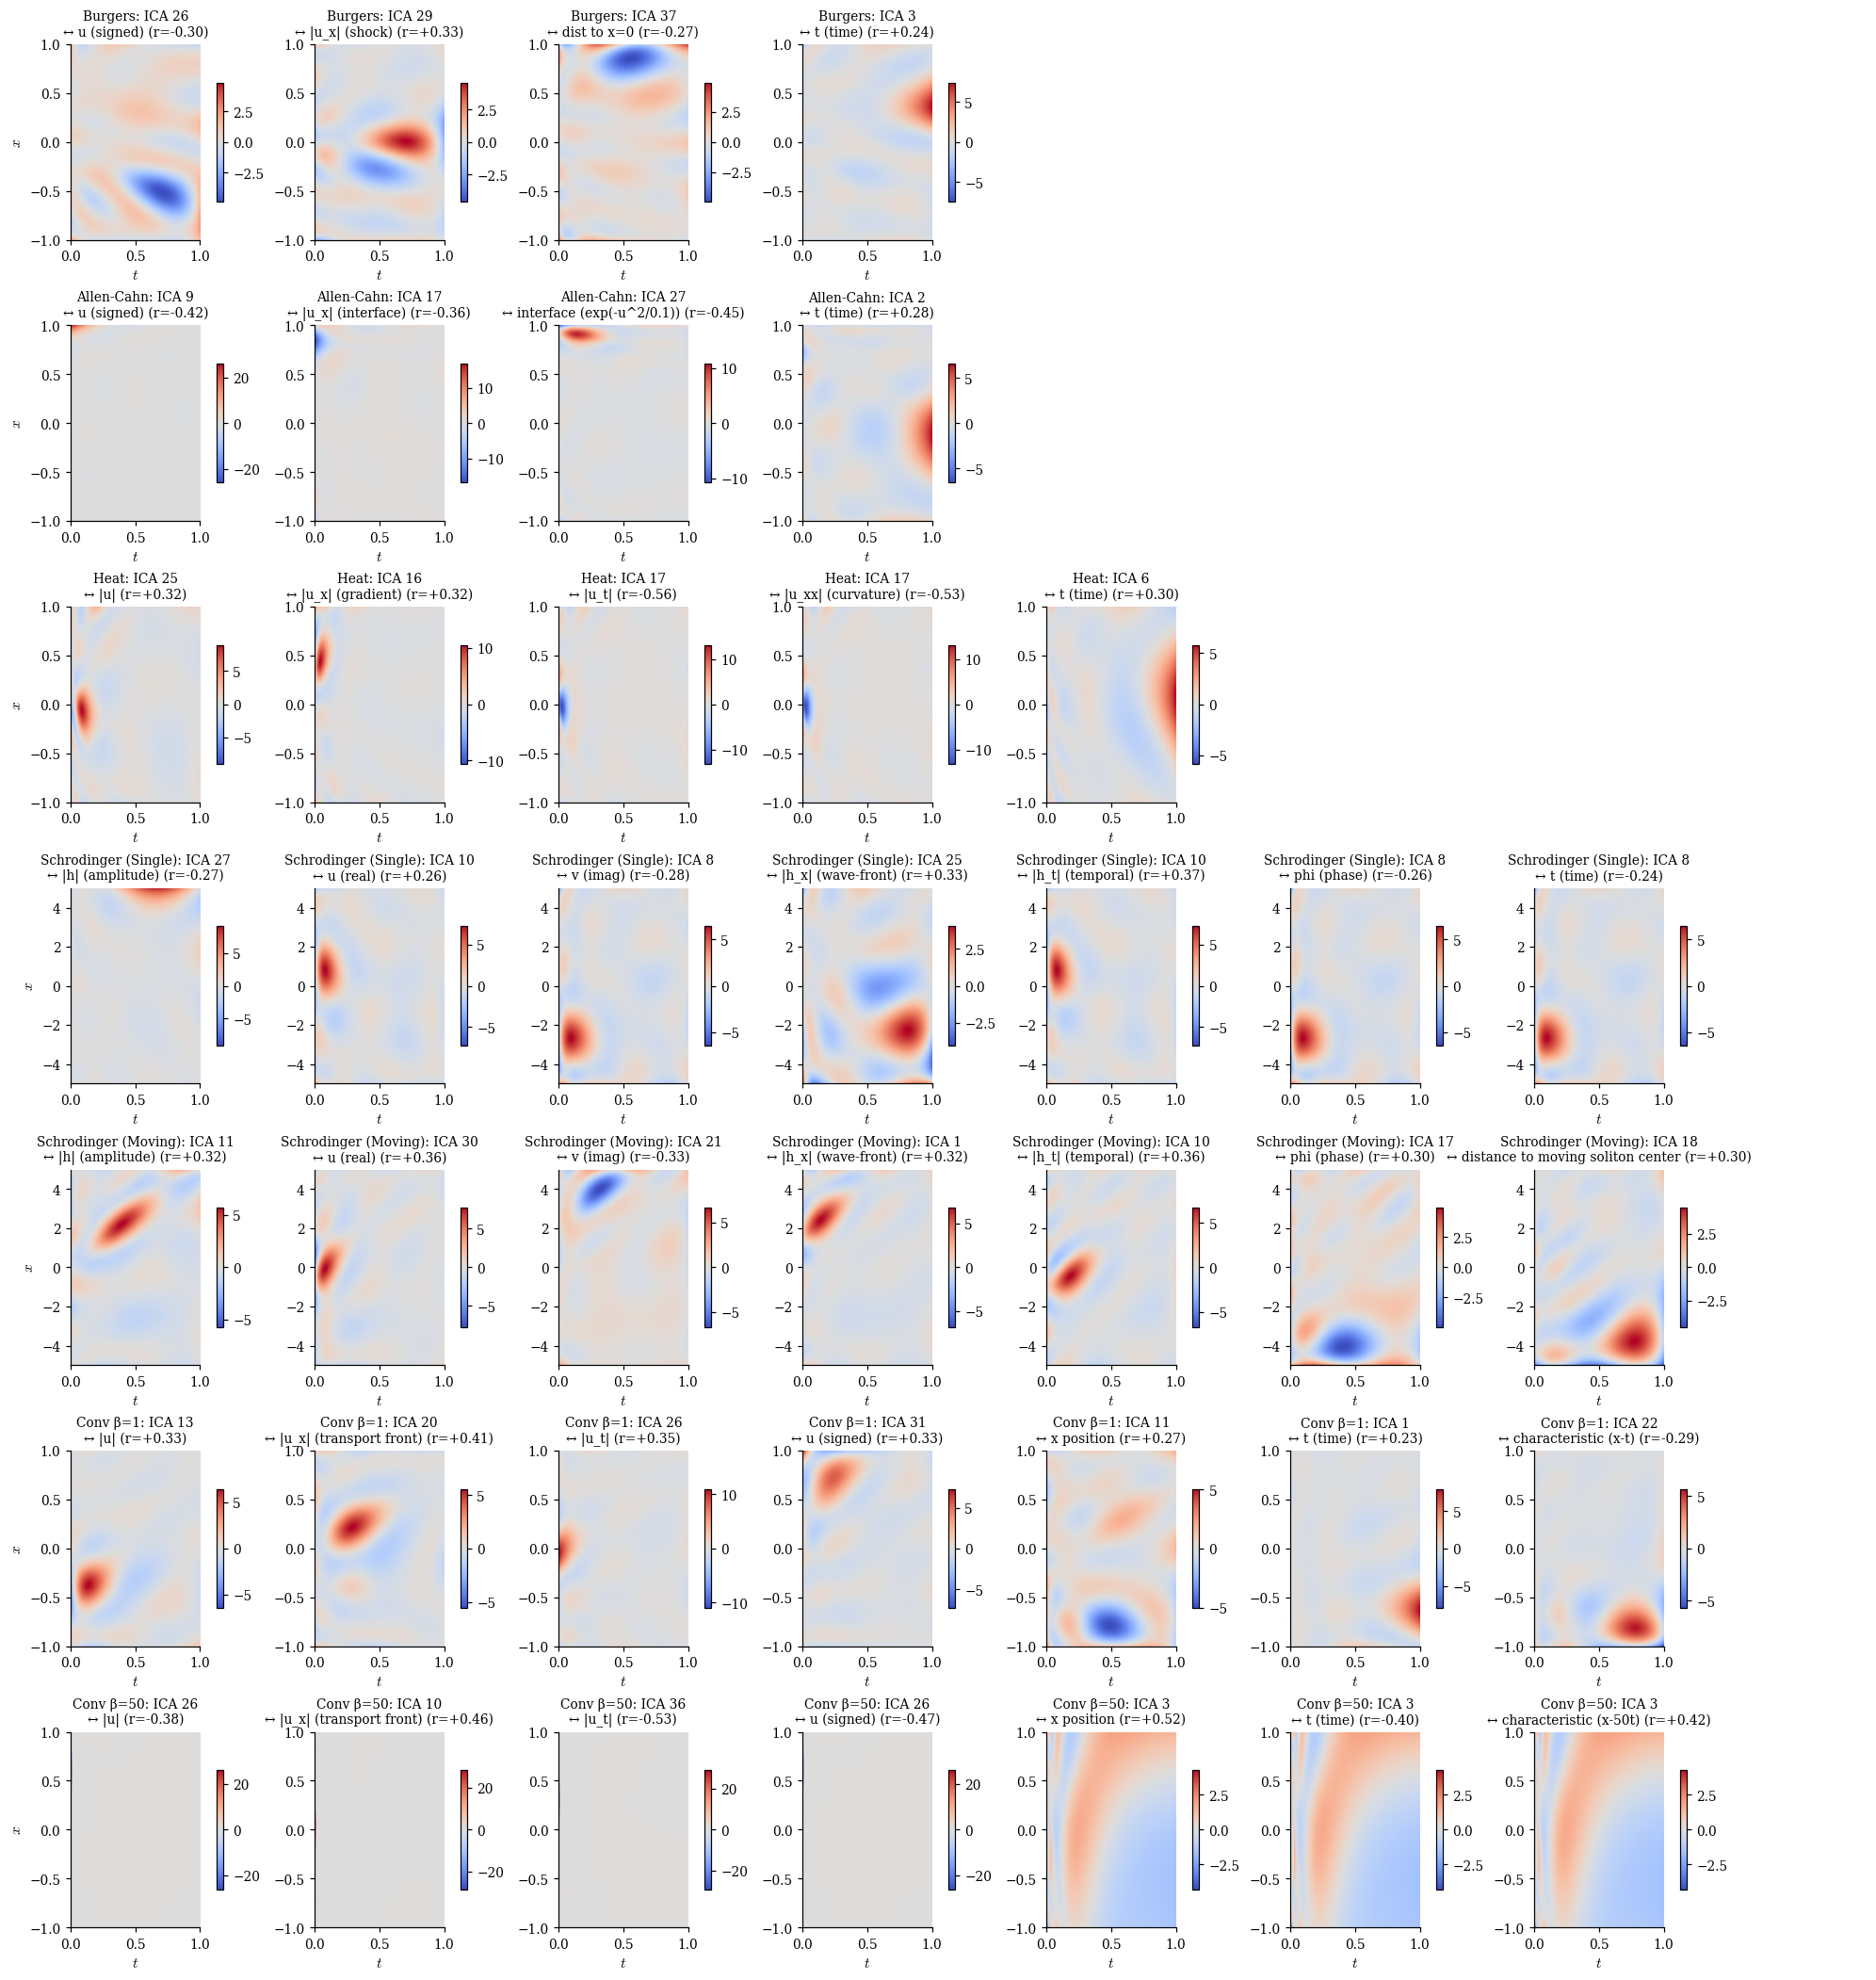

In [15]:
def fig3(d_list):

    fig, axes = plt.subplots(7,8,figsize=(18, 19),constrained_layout=True)
    for row, (Z, A, names, concept_subset, tag) in enumerate(d_list):
        current_extent = extent_s if "Schrodinger" in tag else extent
        for j_idx, cname in enumerate(concept_subset):

            j = names.index(cname)
            k_top = int(np.argmax(np.abs(A[:, j])))
            r = A[k_top, j]
            zk = Z[..., k_top]
            ax = axes[row, j_idx]
            vmax = zk.max()
            vmax = np.abs(zk).max()
            im = ax.imshow(zk,extent=current_extent,origin="lower",aspect="auto",cmap="coolwarm",vmin=-vmax,vmax=vmax)
            ax.set_title(f"{tag}: ICA {k_top}\n↔ {cname} (r={r:+.2f})",fontsize=9)
            ax.set_xlabel("$t$")

            if j_idx == 0:
                ax.set_ylabel("$x$")

            plt.colorbar(im,ax=ax,fraction=0.046)

        # hide unused columns
        for k in range(len(concept_subset), 8):
            axes[row, k].axis("off")

    plt.savefig("figures/fig3_ica.png",bbox_inches="tight")
    plt.show()


burgers_concepts_show = ["u (signed)","|u_x| (shock)","dist to x=0","t (time)"]
ac_concepts_show = ["u (signed)","|u_x| (interface)","interface (exp(-u^2/0.1))","t (time)"]
heat_concepts_show = ["|u|","|u_x| (gradient)","|u_t|","|u_xx| (curvature)","t (time)"]
sch_single_concepts_show = ["|h| (amplitude)","u (real)","v (imag)","|h_x| (wave-front)","|h_t| (temporal)","phi (phase)","t (time)"]
sch_moving_concepts_show = ["|h| (amplitude)","u (real)","v (imag)","|h_x| (wave-front)","|h_t| (temporal)","phi (phase)","distance to moving soliton center"]
conv1_concepts_show = ["|u|","|u_x| (transport front)","|u_t|","u (signed)","x position","t (time)","characteristic (x-t)"]
conv50_concepts_show = ["|u|","|u_x| (transport front)","|u_t|","u (signed)","x position","t (time)","characteristic (x-50t)"]


fig3([(Z_b, A_b, names_b, burgers_concepts_show, "Burgers"),
      (Z_a, A_a, names_a,ac_concepts_show,"Allen-Cahn"),
      (Z_h, A_h, names_h,heat_concepts_show,"Heat"),
      (Z_s_s, A_s_s, names_s_s,sch_single_concepts_show,"Schrodinger (Single)"),
      (Z_s_m, A_s_m, names_s_m,sch_moving_concepts_show,"Schrodinger (Moving)"),
      (Z_c1, A_c1, names_c1,conv1_concepts_show,"Conv β=1"),
      (Z_c50, A_c50, names_c50,conv50_concepts_show,"Conv β=50")])

# 9. Ablation — closed-loop causal check - Figure 4



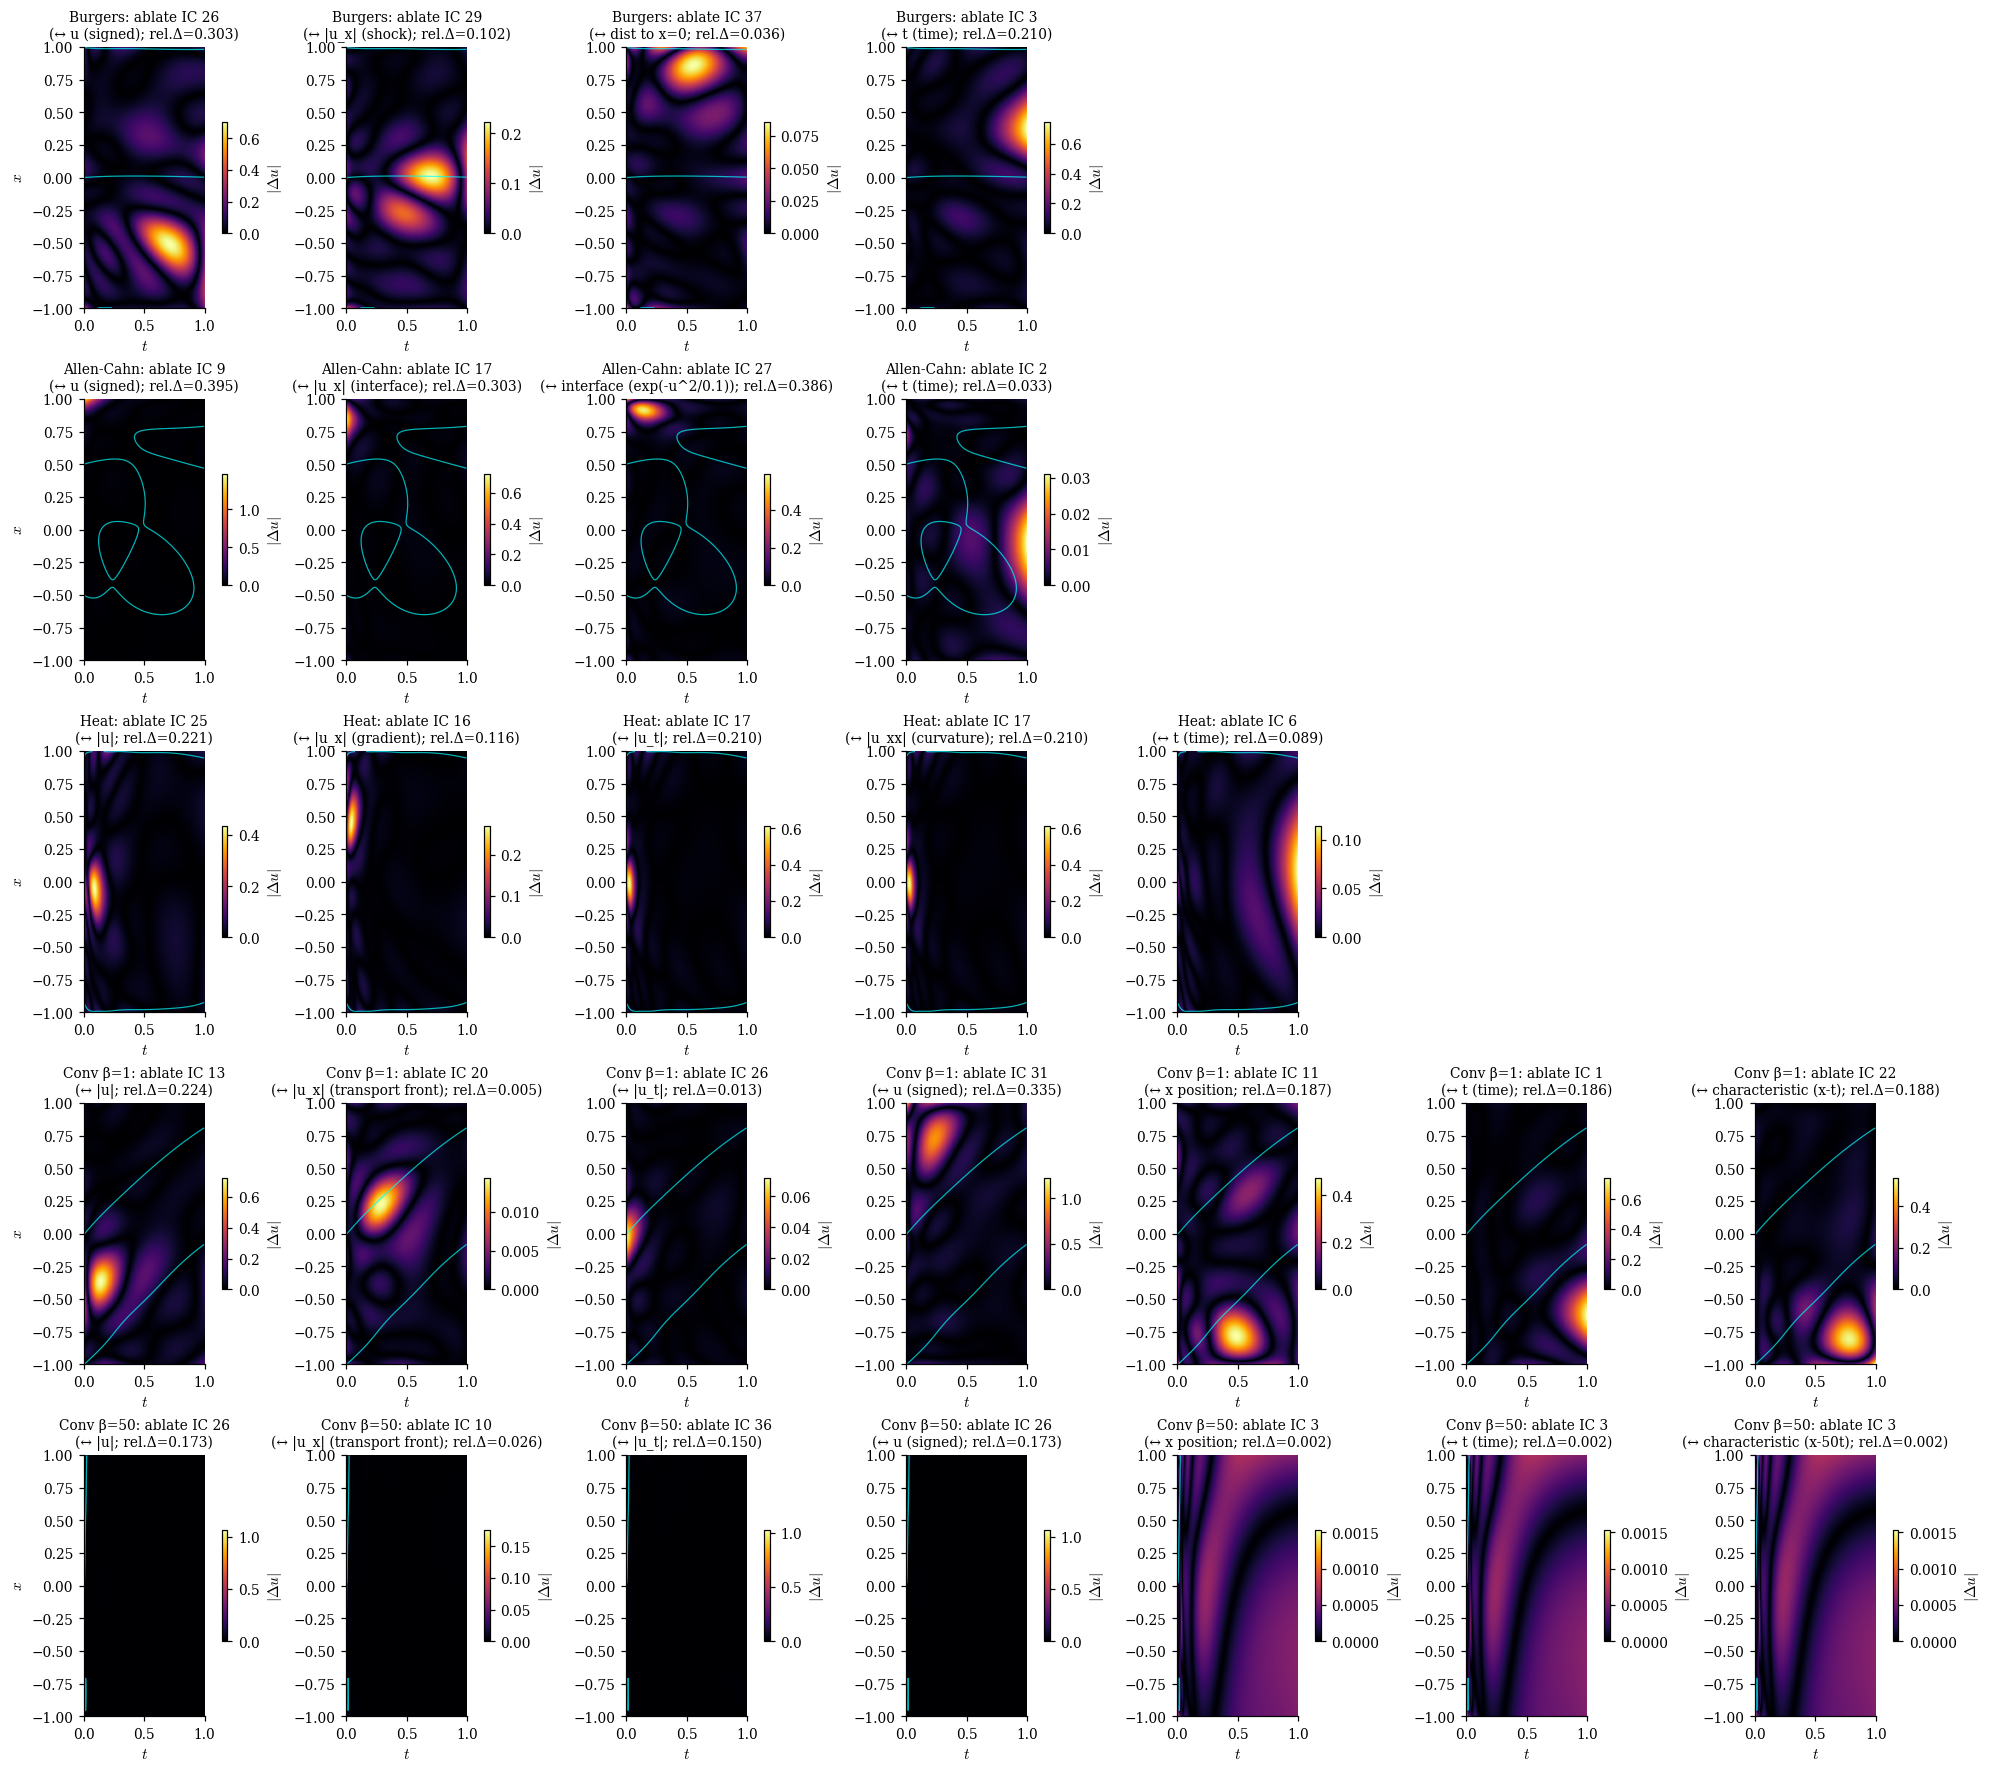

In [16]:
def intervene_ablate_ica(pinn, ica, H, mu, sd, ic_idx):

    # flatten hidden activations
    H_flat = H.reshape(-1, HIDDEN)
    # normalize
    H_norm = (H_flat - mu) / sd
    # ICA encoding
    Z = ica.transform(H_norm)
    # reconstruction
    H_recon_norm = ica.inverse_transform(Z)
    # ablate one independent component
    Z_mod = Z.copy()
    Z_mod[:, ic_idx] = 0.0
    H_mod_norm = ica.inverse_transform(Z_mod)
    # undo normalization
    H_recon = H_recon_norm * sd + mu
    H_mod   = H_mod_norm   * sd + mu
    # frozen PINN readout
    W = pinn.net[-1].weight.detach().numpy()
    b = pinn.net[-1].bias.detach().numpy()
    u_recon = (H_recon @ W.T + b).reshape(nx, nt)
    u_mod   = (H_mod   @ W.T + b).reshape(nx, nt)
    delta = u_recon - u_mod

    return u_recon, u_mod, delta


# Visualization

def fig4(items):
    max_cols = max(len(x[-2]) for x in items)
    fig, axes = plt.subplots(len(items),max_cols,figsize=(18,16),constrained_layout=True)

    if len(items) == 1:
        axes = np.expand_dims(axes,0)

    for row, (pinn,ica,H,mu,sd,A,names,U,concepts_to_show,tag) in enumerate(items):
        for j_idx, cname in enumerate(concepts_to_show):
            j = names.index(cname)
            # top aligned independent component
            ic = int(np.argmax(np.abs(A[:,j])))

            u_recon, u_mod, delta = intervene_ablate_ica(pinn,ica,H,mu,sd,ic)
            rel = np.linalg.norm(delta) / (np.linalg.norm(u_recon)+1e-12)
            ax = axes[row,j_idx]
            vmax = np.abs(delta).max()
            im = ax.imshow(np.abs(delta),extent=extent,origin="lower",aspect="auto",cmap="inferno",vmin=0,vmax=vmax if vmax>0 else 1)
            ax.contour(U,levels=[0.0],extent=extent,origin="lower",colors="cyan",linewidths=0.8,alpha=0.7)
            ax.set_title(
                f"{tag}: ablate IC {ic}\n"
                f"(↔ {cname}; rel.Δ={rel:.3f})",
                fontsize=9
            )

            ax.set_xlabel("$t$")

            if j_idx == 0:
                ax.set_ylabel("$x$")

            plt.colorbar(im,ax=ax,fraction=0.046,label=r"$|\Delta u|$")

        # hide unused columns
        for k in range(len(concepts_to_show), max_cols):
            axes[row,k].axis("off")

    plt.savefig("figures/fig4_ica_intervention.png",bbox_inches="tight")
    plt.show()


# Run
fig4([
    (pinn_b,ica_b,H_b,mu_b,sd_b,A_b,names_b,U_b,burgers_concepts_show,"Burgers"),
    (pinn_a,ica_a,H_a,mu_a,sd_a,A_a,names_a,U_a,ac_concepts_show,"Allen-Cahn"),
    (pinn_h,ica_h,H_h,mu_h,sd_h,A_h,names_h,U_h,heat_concepts_show,"Heat"),
    (conv_models[1],ica_c1,H_c1,mu_c1,sd_c1,A_c1,names_c1,U_c1,conv1_concepts_show,"Conv β=1"),
    (conv_models[50],ica_c50,H_c50,mu_c50,sd_c50,A_c50,names_c50,U_c50,conv50_concepts_show,"Conv β=50")
])

## ablation for schrodinger - single and moving soliton

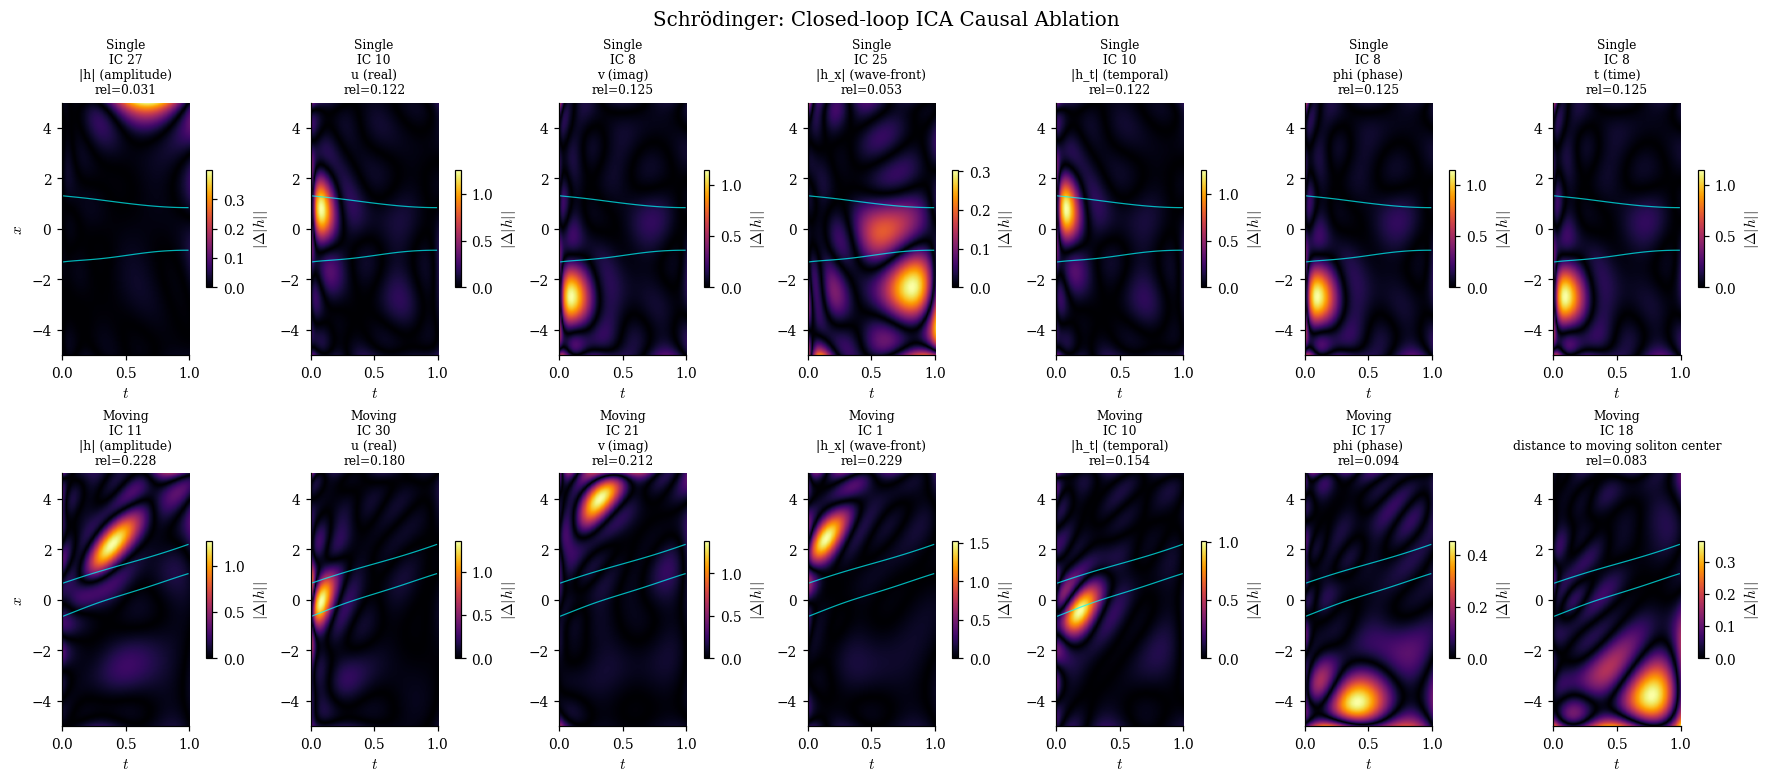

In [17]:
def intervene_ablate_schrodinger_ica(pinn, ica, H, mu, sd, ic_idx):

    # flatten hidden activations
    H_flat = H.reshape(-1, HIDDEN)
    # normalize
    H_norm = (H_flat - mu) / sd
    # ICA encoding
    Z = ica.transform(H_norm)
    # reconstruction
    H_recon_norm = ica.inverse_transform(Z)
    # ablate one independent component
    Z_mod = Z.copy()
    Z_mod[:, ic_idx] = 0.0
    H_mod_norm = ica.inverse_transform(Z_mod)
    # undo normalization
    H_recon = H_recon_norm * sd + mu
    H_mod   = H_mod_norm   * sd + mu
    # Frozen PINN readout
    W = pinn.net[-1].weight.detach().numpy()
    b = pinn.net[-1].bias.detach().numpy()
    uv_recon = H_recon @ W.T + b
    uv_mod   = H_mod   @ W.T + b
    u_recon = uv_recon[:,0].reshape(nx, nt)
    v_recon = uv_recon[:,1].reshape(nx, nt)
    u_mod = uv_mod[:,0].reshape(nx, nt)
    v_mod = uv_mod[:,1].reshape(nx, nt)
    amp_recon = np.sqrt(u_recon**2 + v_recon**2)
    amp_mod   = np.sqrt(u_mod**2 + v_mod**2)

    delta = np.sqrt((u_recon-u_mod)**2 +(v_recon-v_mod)**2)
    return amp_recon, amp_mod, delta


# Visualization
extent_s = [0,1,-5,5]
fig, axes = plt.subplots(2,7,figsize=(16,7),constrained_layout=True)
rows = [
    ("Single",pinn_s_s,ica_s_s,H_s_s,mu_s_s,sd_s_s,A_s_s,names_s_s,AMP_s_fig_single,sch_single_concepts_show),
    ("Moving",pinn_s_m,ica_s_m,H_s_m,mu_s_m,sd_s_m,A_s_m,names_s_m,AMP_s_fig_moving,sch_moving_concepts_show)
]

for row, (tag,pinn,ica,H,mu,sd,A,names,AMP_fig,concepts_show) in enumerate(rows):
    for j_idx, cname in enumerate(concepts_show):

        j = names.index(cname)
        # top aligned independent component
        ic = int(np.argmax(np.abs(A[:, j])))

        amp_recon, amp_mod, delta = intervene_ablate_schrodinger_ica(pinn,ica,H,mu,sd,ic)
        rel = np.linalg.norm(delta) / (np.linalg.norm(amp_recon) + 1e-12)
        ax = axes[row, j_idx]

        vmax = np.abs(delta).max()

        im = ax.imshow(np.abs(delta),extent=extent_s,origin="lower",aspect="auto",cmap="inferno",vmin=0,vmax=vmax if vmax > 0 else 1)
        ax.contour(AMP_fig,levels=[1.0],extent=extent_s,origin="lower",colors="cyan",linewidths=0.8,alpha=0.7)
        ax.set_title(
            f"{tag}\n"
            f"IC {ic}\n"
            f"{cname}\n"
            f"rel={rel:.3f}",
            fontsize=8
        )

        ax.set_xlabel("$t$")

        if j_idx == 0:
            ax.set_ylabel("$x$")

        plt.colorbar(im,ax=ax,fraction=0.046,label=r"$|\Delta |h||$")

plt.suptitle("Schrödinger: Closed-loop ICA Causal Ablation",fontsize=13)
plt.savefig("figures/fig4_schrodinger_ica_intervention.png",bbox_inches="tight")
plt.show()